### Import libraries and dataset

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv("carclaims.csv")

In [53]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '', regex=True)
)
df.columns

Index(['month', 'weekofmonth', 'dayofweek', 'make', 'accidentarea',
       'dayofweekclaimed', 'monthclaimed', 'weekofmonthclaimed', 'sex',
       'maritalstatus', 'age', 'fault', 'policytype', 'vehiclecategory',
       'vehicleprice', 'policynumber', 'repnumber', 'deductible',
       'driverrating', 'dayspolicyaccident', 'dayspolicyclaim',
       'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder',
       'policereportfiled', 'witnesspresent', 'agenttype',
       'numberofsuppliments', 'addresschangeclaim', 'numberofcars', 'year',
       'basepolicy', 'fraudfound'],
      dtype='object')

### Data Overview

In [54]:
print("Shape:", df.shape)
df.head()

Shape: (15420, 33)


,month,weekofmonth,dayofweek,make,accidentarea,dayofweekclaimed,monthclaimed,weekofmonthclaimed,sex,maritalstatus,...,ageofpolicyholder,policereportfiled,witnesspresent,agenttype,numberofsuppliments,addresschangeclaim,numberofcars,year,basepolicy,fraudfound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   month                15420 non-null  object
 1   weekofmonth          15420 non-null  int64 
 2   dayofweek            15420 non-null  object
 3   make                 15420 non-null  object
 4   accidentarea         15420 non-null  object
 5   dayofweekclaimed     15420 non-null  object
 6   monthclaimed         15420 non-null  object
 7   weekofmonthclaimed   15420 non-null  int64 
 8   sex                  15420 non-null  object
 9   maritalstatus        15420 non-null  object
 10  age                  15420 non-null  int64 
 11  fault                15420 non-null  object
 12  policytype           15420 non-null  object
 13  vehiclecategory      15420 non-null  object
 14  vehicleprice         15420 non-null  object
 15  policynumber         15420 non-null  int64 
 16  repn

In [56]:
df.describe()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


### Missing Values & Duplicates

In [62]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.isnull().sum()

month                  0
weekofmonth            0
dayofweek              0
make                   0
accidentarea           0
dayofweekclaimed       0
monthclaimed           0
weekofmonthclaimed     0
sex                    0
maritalstatus          0
age                    0
fault                  0
policytype             0
vehiclecategory        0
vehicleprice           0
policynumber           0
repnumber              0
deductible             0
driverrating           0
dayspolicyaccident     0
dayspolicyclaim        0
pastnumberofclaims     0
ageofvehicle           0
ageofpolicyholder      0
policereportfiled      0
witnesspresent         0
agenttype              0
numberofsuppliments    0
addresschangeclaim     0
numberofcars           0
year                   0
basepolicy             0
fraudfound             0
dtype: int64

<Axes: >

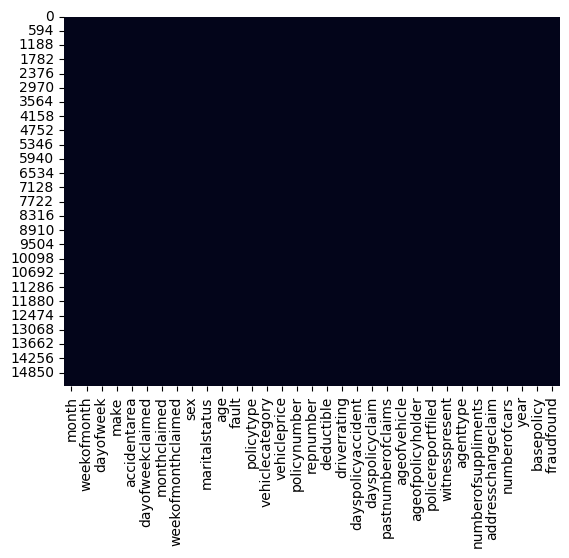

In [58]:
sns.heatmap(df.isnull(), cbar=False)

### Fraud Count and Percentage

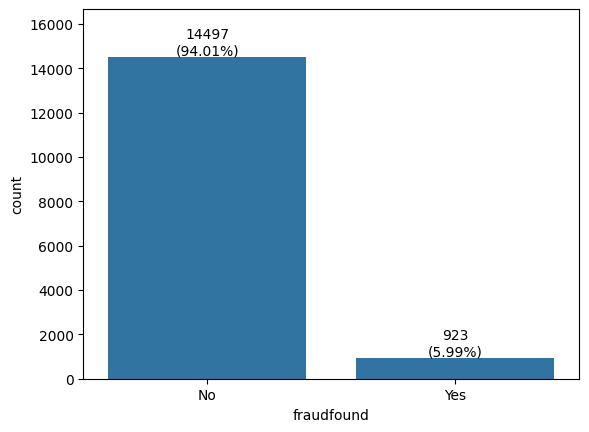

In [59]:
ax = sns.countplot(x="fraudfound", data=df)
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
ax.set_ylim(0, max(df["fraudfound"].value_counts()) * 1.15)

plt.show()

### Univariate analysis

array([[<Axes: title={'center': 'weekofmonth'}>,
        <Axes: title={'center': 'weekofmonthclaimed'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'policynumber'}>,
        <Axes: title={'center': 'repnumber'}>,
        <Axes: title={'center': 'deductible'}>],
       [<Axes: title={'center': 'driverrating'}>,
        <Axes: title={'center': 'year'}>, <Axes: >]], dtype=object)

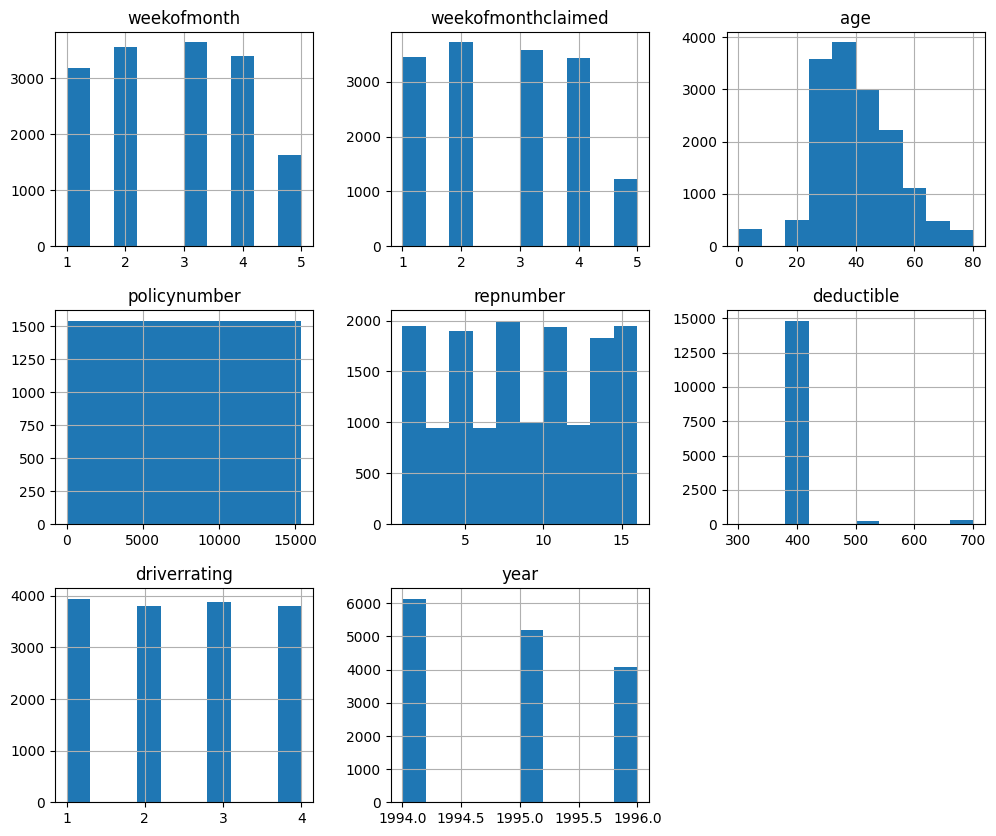

In [60]:
df.hist(figsize=(12,10))

In [65]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print()
print("Categorical columns:", cat_cols)

Numerical columns: ['weekofmonth', 'weekofmonthclaimed', 'age', 'policynumber', 'repnumber', 'deductible', 'driverrating', 'year']

Categorical columns: ['month', 'dayofweek', 'make', 'accidentarea', 'dayofweekclaimed', 'monthclaimed', 'sex', 'maritalstatus', 'fault', 'policytype', 'vehiclecategory', 'vehicleprice', 'dayspolicyaccident', 'dayspolicyclaim', 'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder', 'policereportfiled', 'witnesspresent', 'agenttype', 'numberofsuppliments', 'addresschangeclaim', 'numberofcars', 'basepolicy', 'fraudfound']


### Categorical Feature Distributions

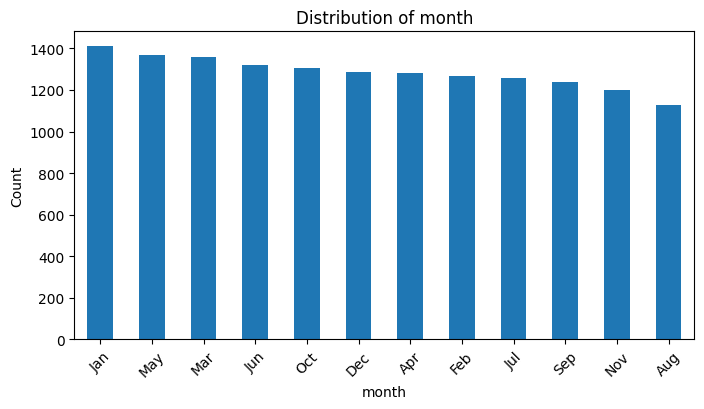

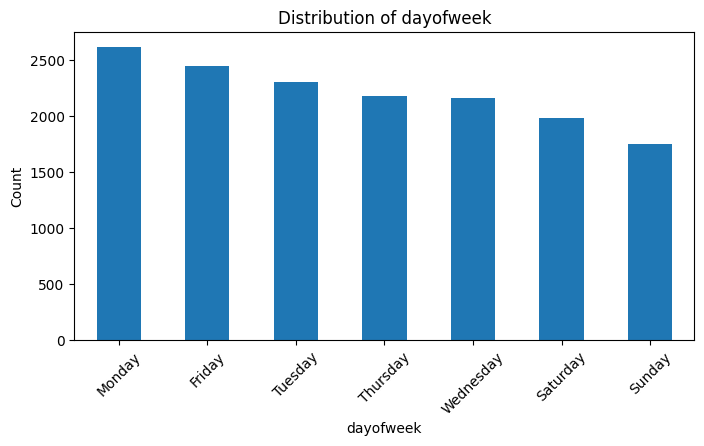

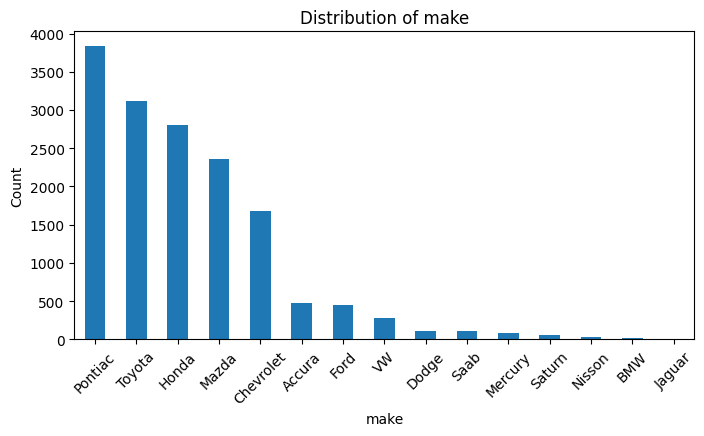

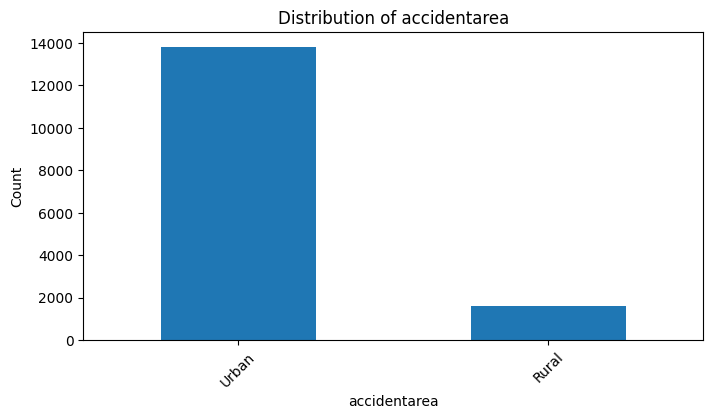

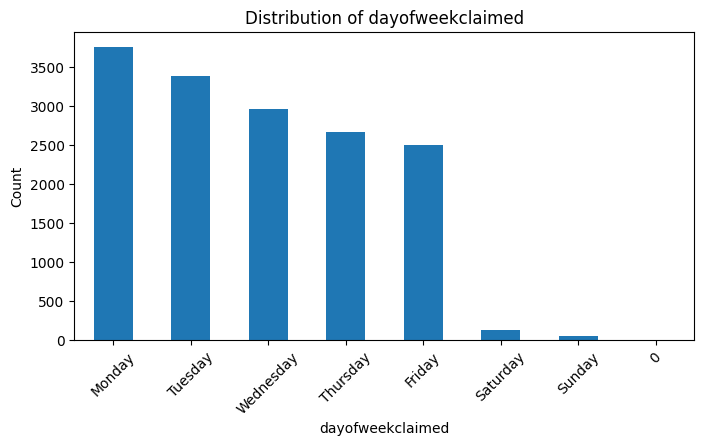

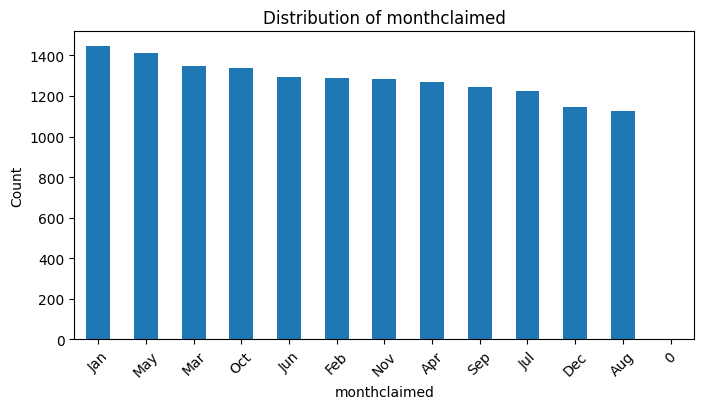

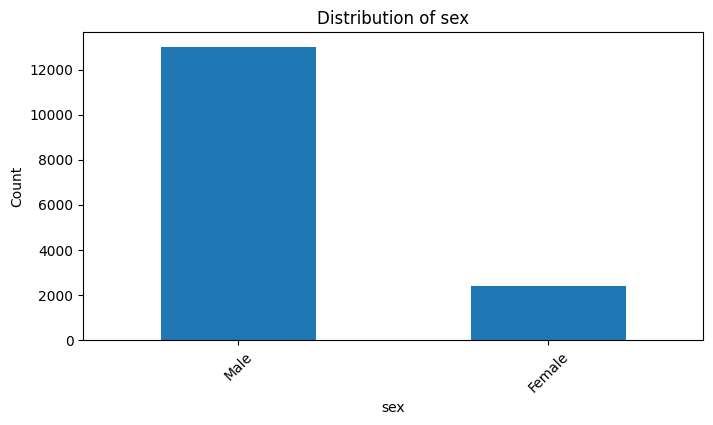

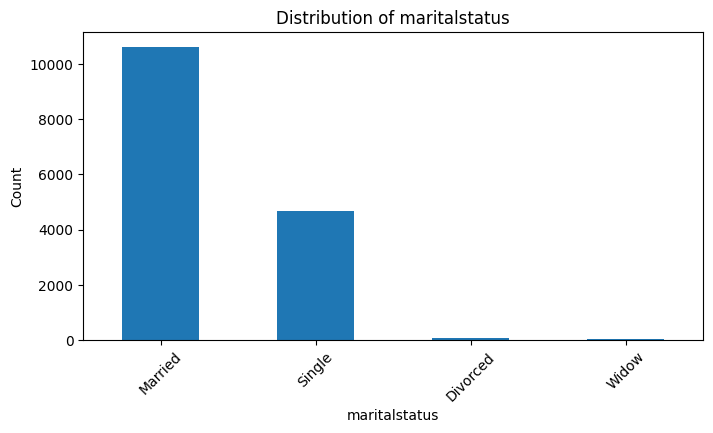

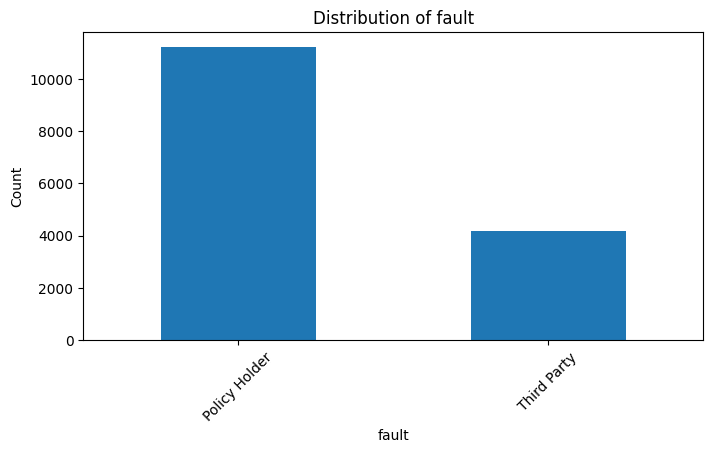

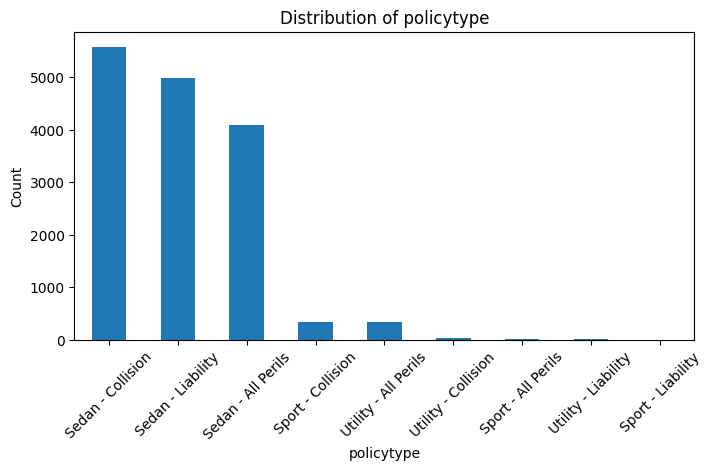

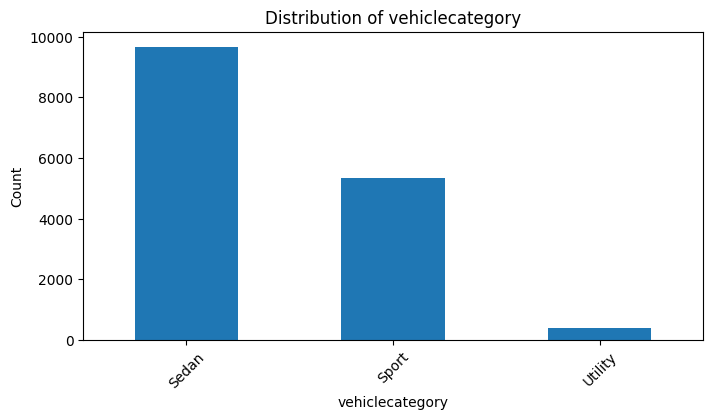

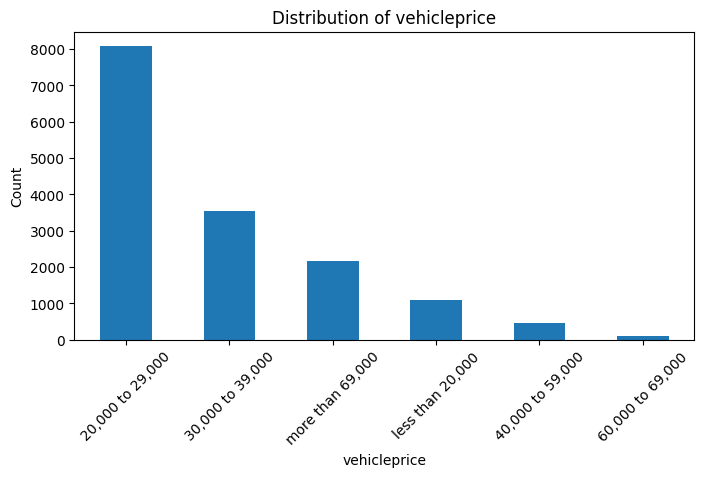

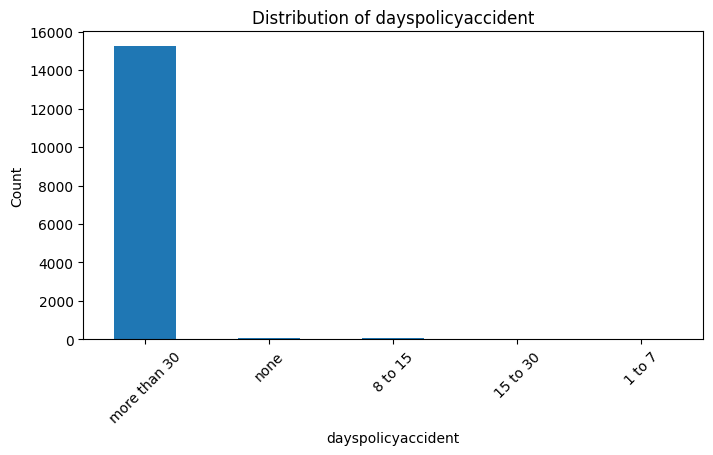

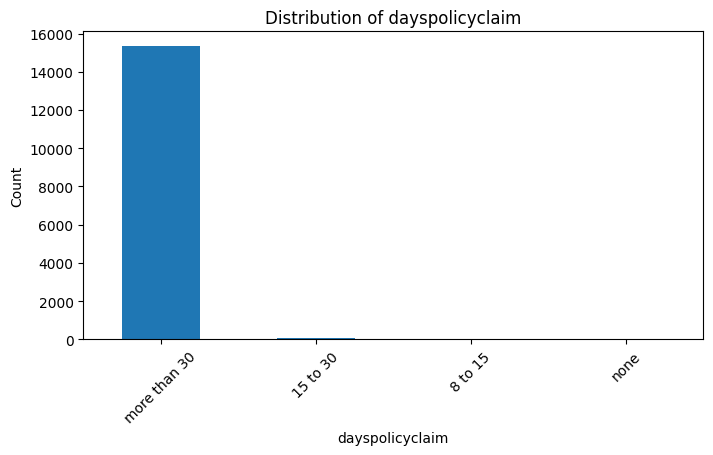

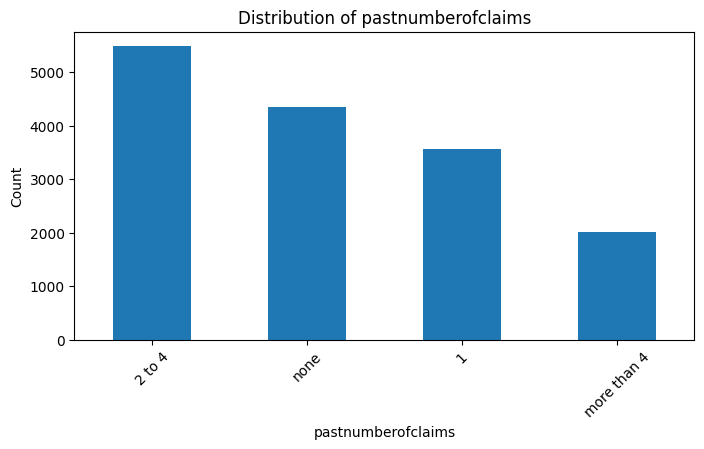

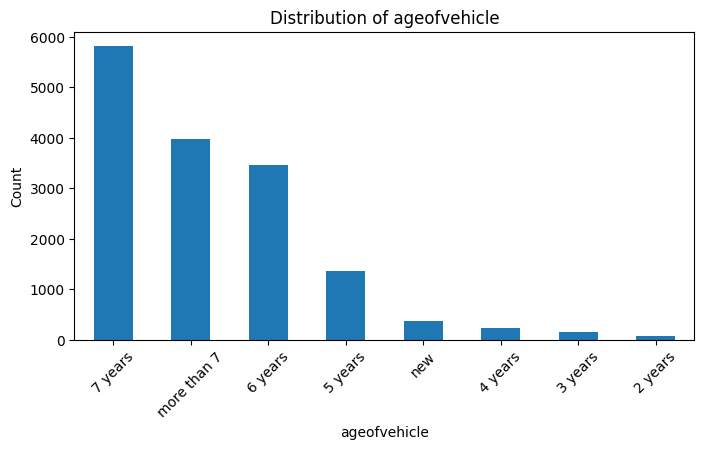

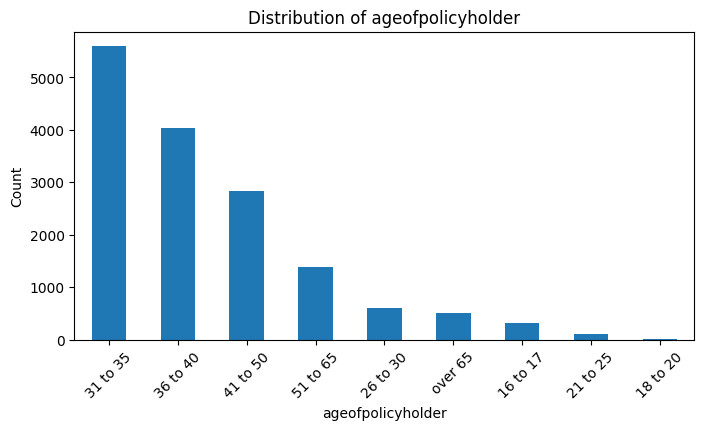

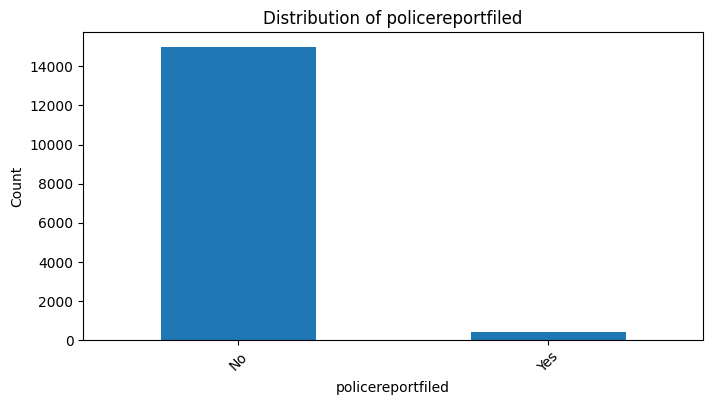

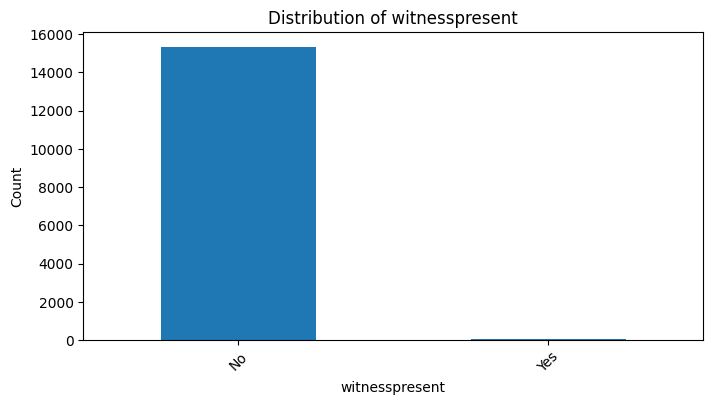

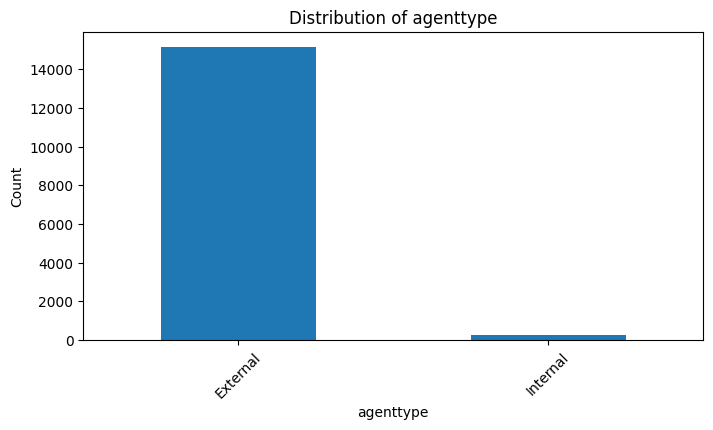

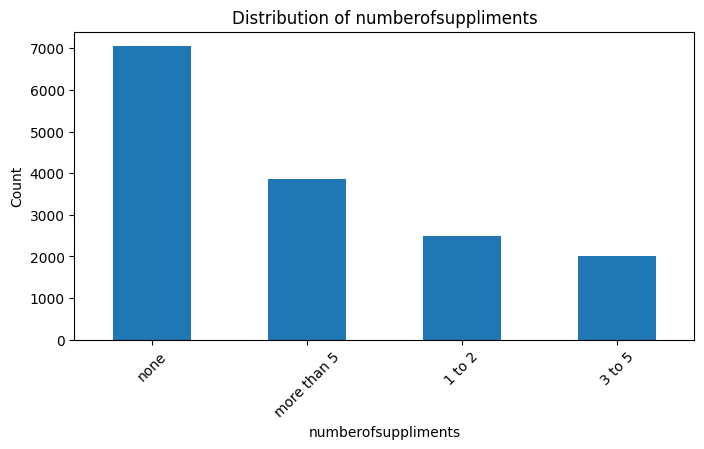

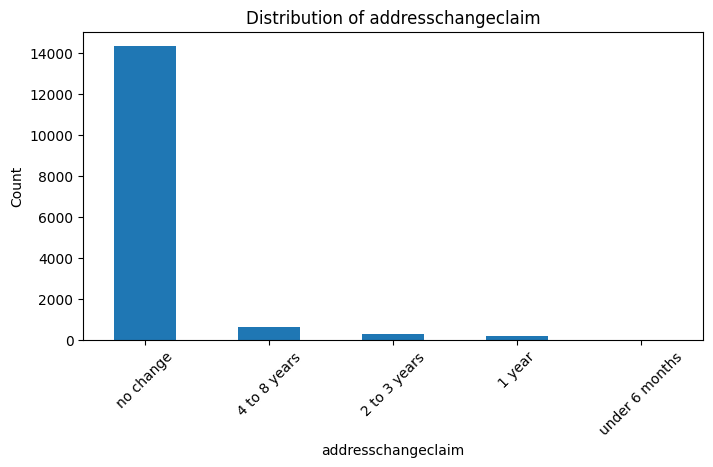

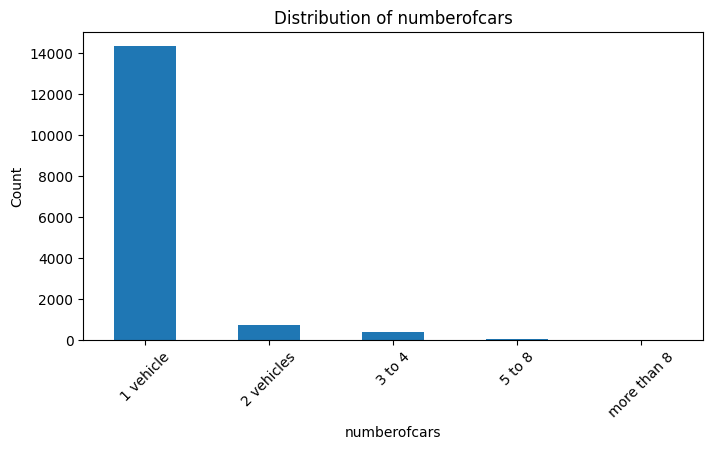

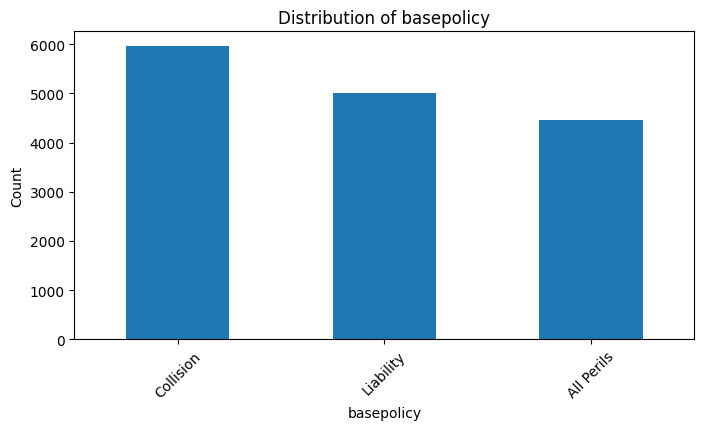

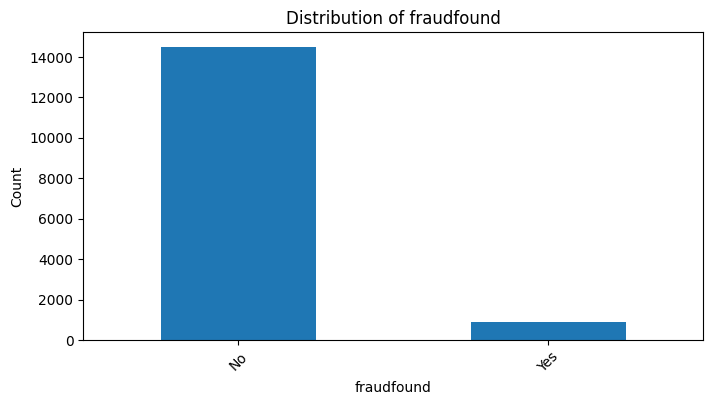

In [70]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

### Fraud vs Non-Fraud: Important Categorical Comparisons

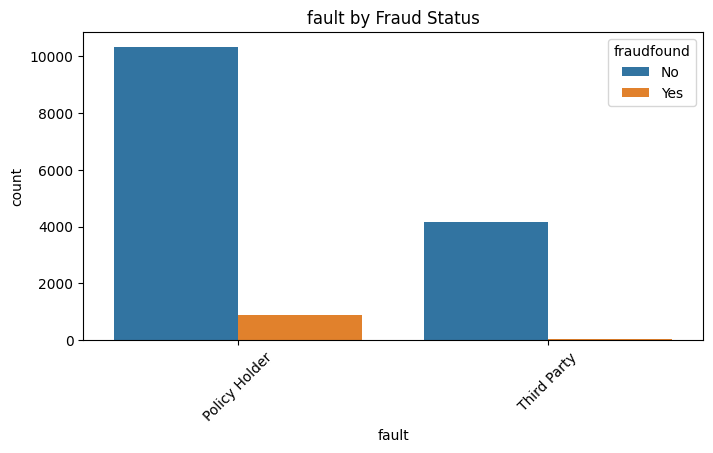

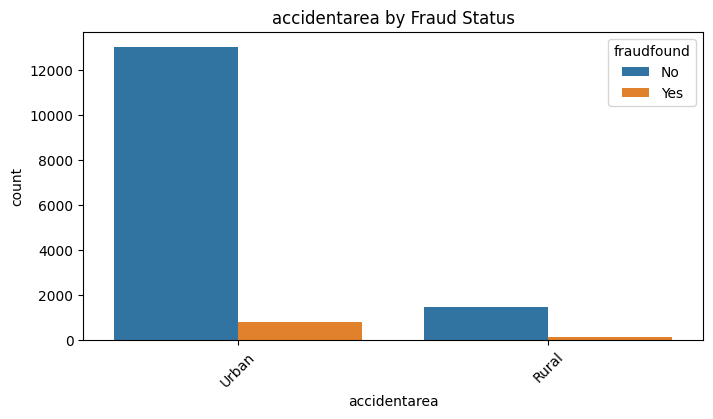

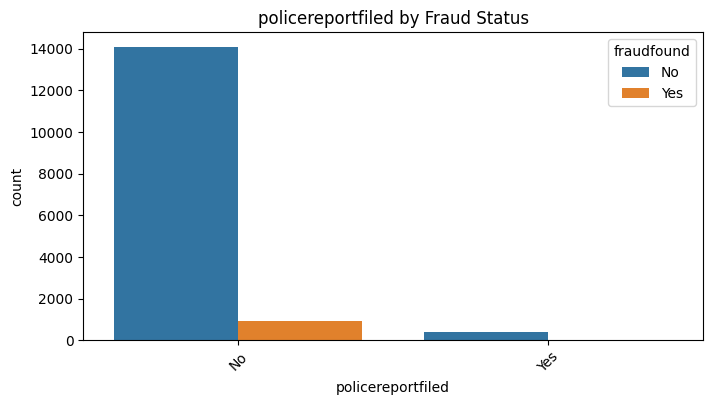

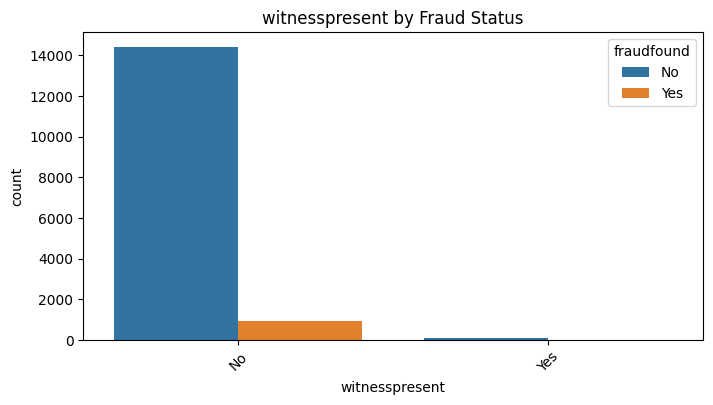

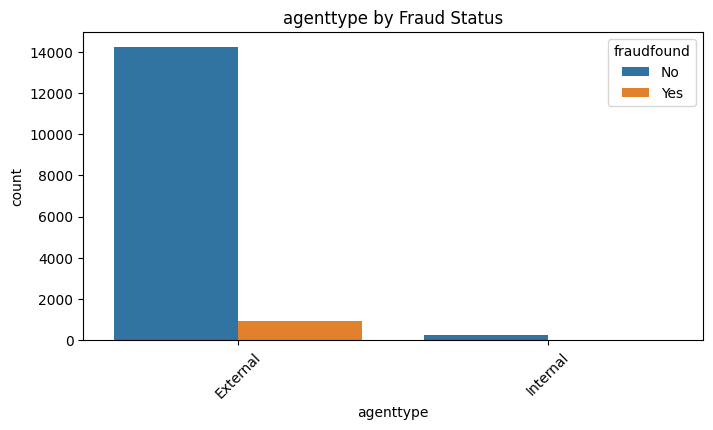

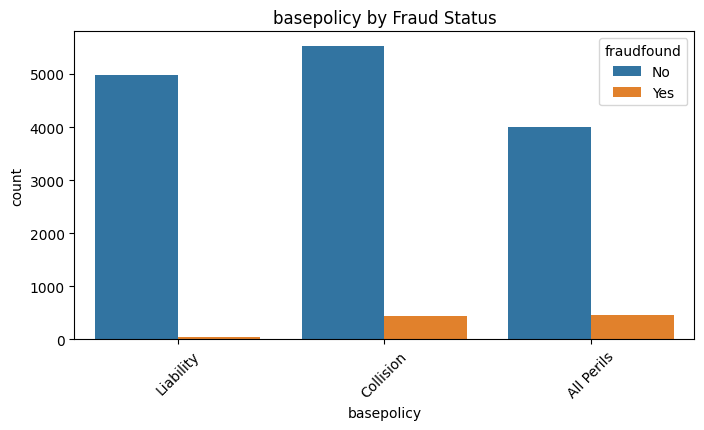

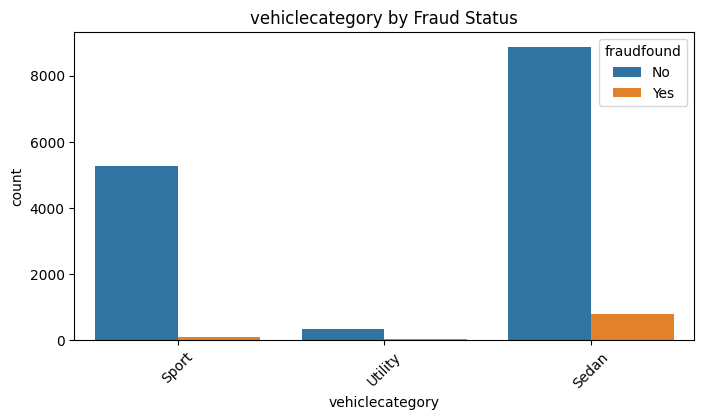

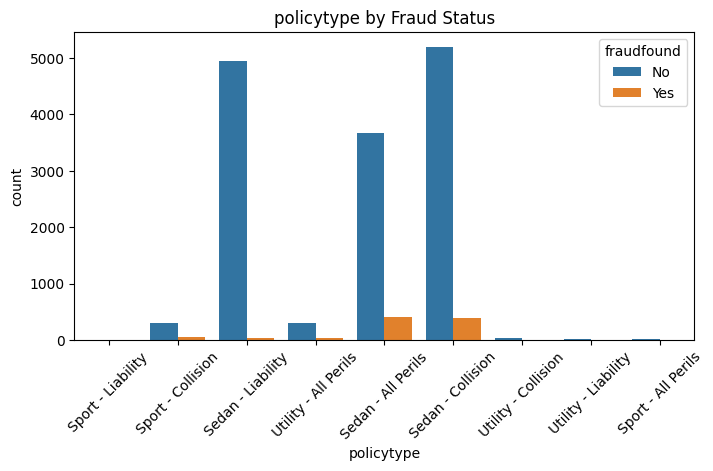

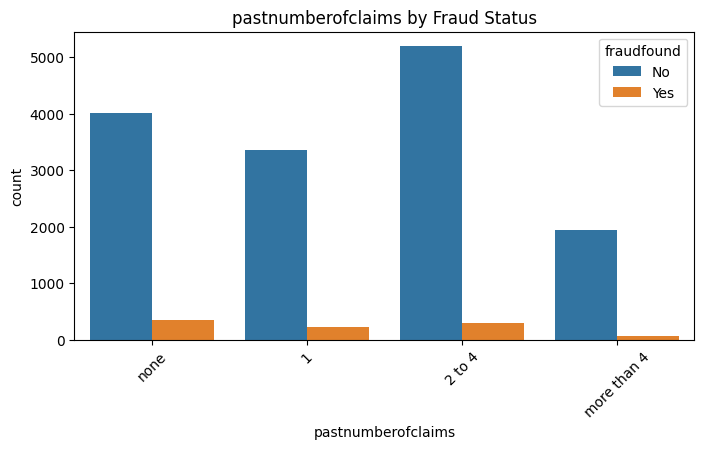

In [71]:

important_cat_cols = [
    "fault",
    "accidentarea",
    "policereportfiled",
    "witnesspresent",
    "agenttype",
    "basepolicy",
    "vehiclecategory",
    "policytype",
    "pastnumberofclaims"
]

for col in important_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue="fraudfound")
        plt.title(f"{col} by Fraud Status")
        plt.xticks(rotation=45)
        plt.show()

### Numerical Features vs Fraud

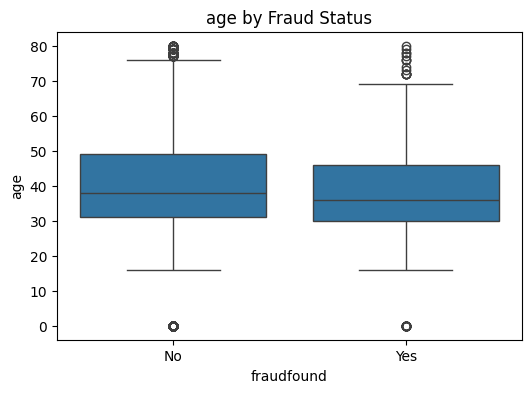

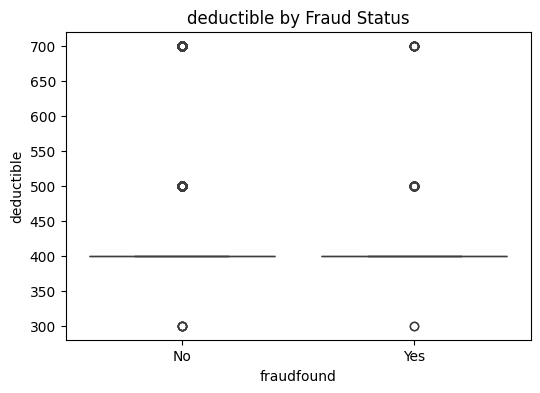

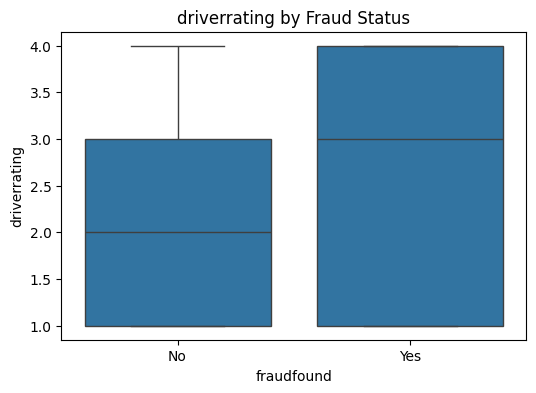

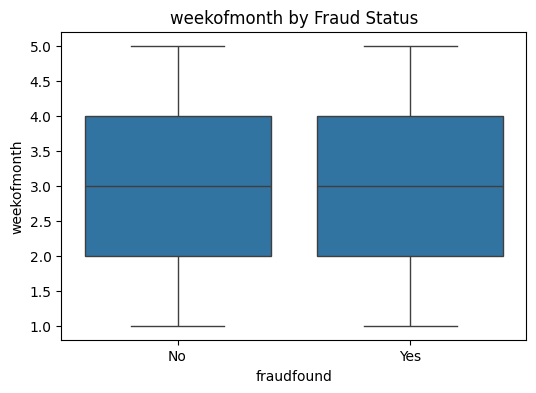

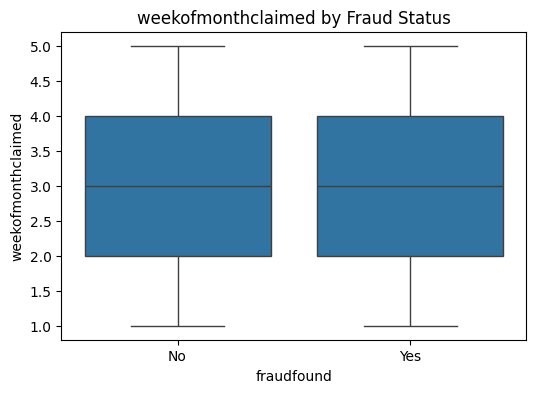

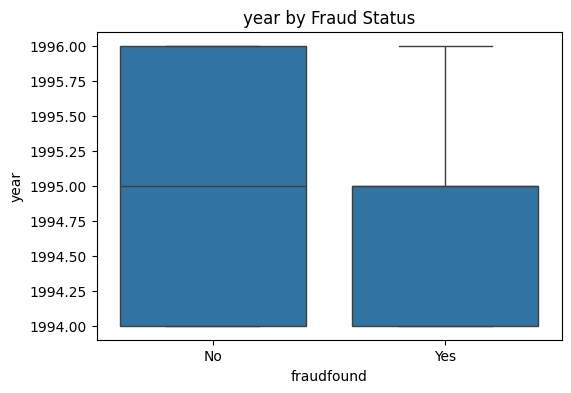

In [72]:
important_num_cols = [
    "age",
    "deductible",
    "driverrating",
    "weekofmonth",
    "weekofmonthclaimed",
    "year"
]

for col in important_num_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x="fraudfound", y=col)
        plt.title(f"{col} by Fraud Status")
        plt.show()

### Grouped Summary by Target

#### Mean

In [73]:
df.groupby("fraudfound")[num_cols].mean()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year
fraudfound,,,,,,,,
No,2.792440,2.695799,39.956957,7733.351038,8.492033,407.511899,2.485756,1994.871491
Yes,2.728061,2.665222,38.265439,7351.592633,8.345612,410.725894,2.520043,1994.787649


#### Median

In [76]:
df.groupby("fraudfound")[num_cols].median()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year
fraudfound,,,,,,,,
No,3.0,3.0,38.0,7755.0,8.0,400.0,2.0,1995.0
Yes,3.0,3.0,36.0,7019.0,8.0,400.0,3.0,1995.0


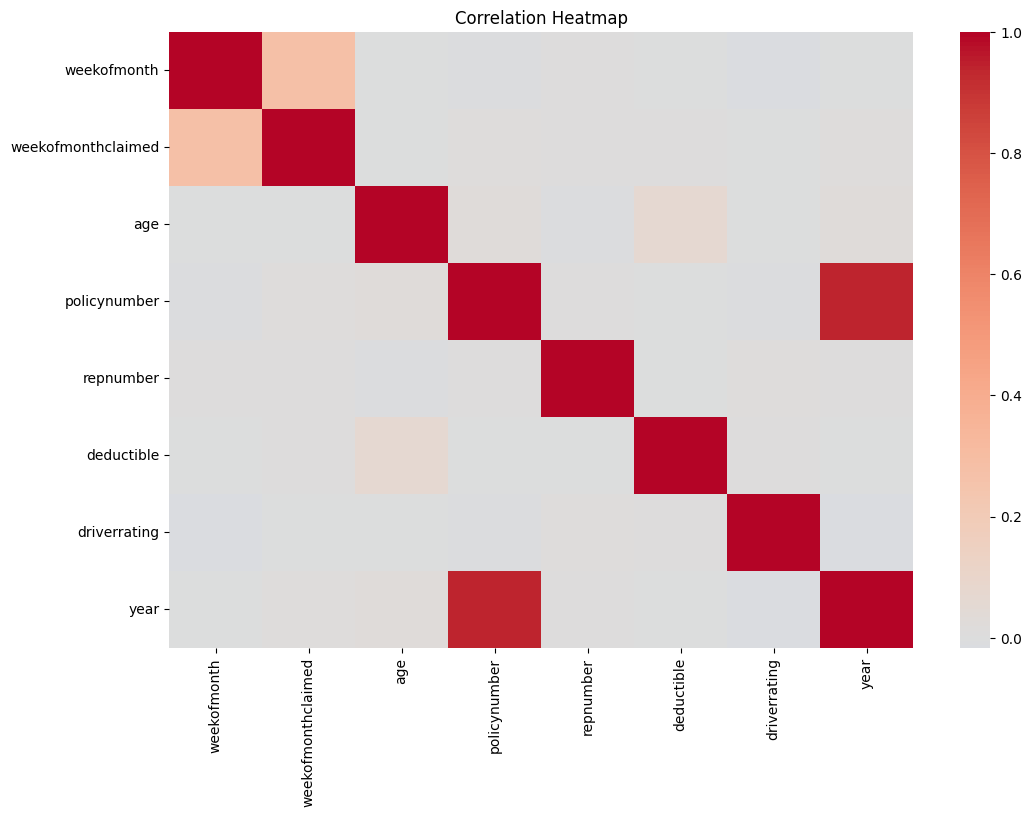

In [77]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()